# Actividades Capítulo 7.


# Tratamiento de datos, estadística descriptiva y visualización de datos

## Resumen de actividades

- **Unidad 34.** Uso de módulos de Python
- **Unidad 35.** Serie Pandas para el tratamiento de datos
- **Unidad 36.** Pandas DataFrame para procesamiento de datos
- **Unidad 37.** Ordenación de datos
- **Unidad 38.** Datos de series temporales



# Actividad: Importación de módulos y su uso.


## Instrucciones

1. Importe los módulos que te permitan trabajar con fechas y tiempo (modulo datetime).

2. Use los diferentes métodos relacinados a operaciones con fechas y hora.

3. En el siguiente apartado revisa cada una las fechas contenidas en la lista e imprima el número de semanas y los dias restantes para llegar a esa fecha.

In [76]:
# Espacio disponible para desarrollar el código y agregar los comentarios necesarios.

import datetime

actual = datetime.datetime.now()                                     # Con esto extraemos la fecha actual y guardamos en la variable actual
actual1 = actual.strftime("%m/%d/%Y")                                # Pasamos la fecha extraida a otra variable para darle un formato más legible
print("la fecha actual de hoy es: ",actual1, "(mes/dia/año)")

date = '01/28/2024'
date2 = '01/22/2024'

lista_de_fechas = ['04/01/2024', '01/28/2024', '03/16/2024', '05/24/2024', '07/30/2025']

y = datetime.datetime.strptime(date,'%m/%d/%Y')                      # De la misma forma le damos un formato más legible a la fecha convertida
#y = y.strftime("%m/%d/%Y")

print("\nTransformación de una cadena a un objeto datetime: ",y)


resultado = actual - y                                               #resultado de resta de fechas

print("\nResultado de resta de fechas (actual - la fecha transformada): ",resultado)

print("\n")
print("_"*94)

def conver(fecha):                                                  #función para convertir una cadena en una fecha de texto a un objeto datetime
  r = datetime.datetime.strptime(fecha, "%m/%d/%Y")
  return r

def semanas(resultado):                                             #función para tomar el resultado de una resta de fechas y devolverla en semanas y días
  r1 = resultado // 7
  r2 = resultado % 7
  return r1, r2

for i in lista_de_fechas:                                           #recorre la lista con las fechas
  var = conver(i)                                                   #transforma los elementos de la lista en objetos datetime
  var1 = var.strftime("%m/%d/%Y")                                   #esa misma transformación de cadena a fecha, le aplicamos un formato más legible sin alterar la original
  resultado = actual - var                                          #restamos fecha actual menos la fecha que aparece en la lista
  resultado1 = resultado.days                                       #convertimos el resultado a dias (numero entero)
  s, d = semanas(resultado1)                                        #llamamos a la función que nos convierta los dias en semanas y los dias que sobre en la operación

  if resultado1 > 0:
    print(f"\nEstamos a {actual1}, restandole la fecha {var1}, desde entonces han pasado: {s} semanas y {d} días")
  else:
    print(f"\nEstamos a {actual1}, restandole la fecha {var1}, faltarían para llegar: {s*-1} semanas y {d} días")




la fecha actual de hoy es:  11/08/2024 (mes/dia/año)

Transformación de una cadena a un objeto datetime:  2024-01-28 00:00:00

Resultado de resta de fechas (actual - la fecha transformada):  285 days, 1:32:43.220671


______________________________________________________________________________________________

Estamos a 11/08/2024, restandole la fecha 04/01/2024, desde entonces han pasado: 31 semanas y 4 días

Estamos a 11/08/2024, restandole la fecha 01/28/2024, desde entonces han pasado: 40 semanas y 5 días

Estamos a 11/08/2024, restandole la fecha 03/16/2024, desde entonces han pasado: 33 semanas y 6 días

Estamos a 11/08/2024, restandole la fecha 05/24/2024, desde entonces han pasado: 24 semanas y 0 días

Estamos a 11/08/2024, restandole la fecha 07/30/2025, faltarían para llegar: 38 semanas y 2 días


# Actividad: Manejo de la biblioteca Pandas.


## Instrucciones


1. Crear una serie de pandas, donde su indice este compuesto por fechas y en columna principal almace los valoras cargados en una lista.

2. Graficar los valores de la lista en función de la fecha.


2024-01-01    140
2024-01-02    130
2024-01-03    120
2024-01-04    115
2024-01-05    160
2024-01-06    110
2024-01-07    170
2024-01-08    150
2024-01-09    157
2024-01-10    135
Freq: D, dtype: int64


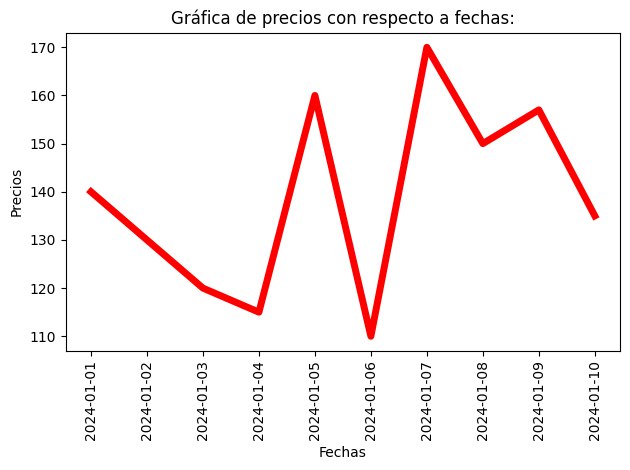

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Espacio para desarrollar el código y agregar los comentarios necesarios.


precios = [140, 130, 120, 115, 160, 110, 170, 150, 157, 135]

fechas = pd.date_range(start="2024-01-01", periods=len(precios)) #10


primera = pd.Series(precios, index = fechas)
print(primera)

plt.plot(fechas, precios, linewidth= 5.0, color="red")
plt.title("Gráfica de precios con respecto a fechas:")
plt.xlabel("Fechas")
plt.ylabel("Precios")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



# Actividad: Operaciones con Data Frames


## Instrucciones


1. Dado el siguiente diccionario construya un objeto DataFrame.
2. Filtre los resultados por año de publicación.
3. Obtenga algunas columnas basado en que contenga alguna palabra en el nombre de la publicacion.


In [90]:
import pandas as pd

publicaciones_literarias = {
    1605: "Don Quijote de la Mancha - Miguel de Cervantes",
    1865: "Alicia en el país de las maravillas - Lewis Carroll",
    1949: "1984 - George Orwell",
    1954: "El Señor de los Anillos - J.R.R. Tolkien",
    1997: "Harry Potter y la piedra filosofal - J.K. Rowling",
    2003: "El Código Da Vinci - Dan Brown"
}


# Espacio para desarrollar el código y agregar los comentarios necesarios.

#creamos el DataFrame pero modificando el diccionario generando una lista de tuplas a partir del mismo en lugar de clave valor.
df_publicaciones = pd.DataFrame(list(publicaciones_literarias.items()))
df_publicaciones.columns = ["Fechas", "Obras"]


print("DataFrame original:")

print(df_publicaciones)


df_filtrado = df_publicaciones[df_publicaciones["Fechas"] > 1950]

#se mostrará el el DataFrame filtrado coon la condición
print("\nPublicaciones después de 1950:")
print(df_filtrado)

#se obtiene las columnas que contengan la palabra "El"
df_con_el = df_publicaciones[df_publicaciones["Obras"].str.contains("El")]


print("\nPublicaciones que contienen 'El':")
print(df_con_el)



# df_publicaciones["Fechas"]                   resumen de una lista en particular
# df.index = ["n1", "n2", "n3", "n4", "n5"]    filas
# df.columns = ["saldo1", "saldo2"]            columnas
# df.rename(index=("n1:edad"), inplace=True)   para renombrar una fila y modificarlo en el dataframe original
# df.rename(columns=("n1:edad"), inplace=True) sin el inplace queda como modificación de una copia
# print("Shape", df.shape)                     cantidad de filas y cantidad de columnas
# print("columnas", df.columns)                imprimir las columnas especificando su nombre
# print("Valores", df.values)                  devuelve los valores de la tabla interna, sin el titulo de la fila o columna


DataFrame original:
   Fechas                                              Obras
0    1605     Don Quijote de la Mancha - Miguel de Cervantes
1    1865  Alicia en el país de las maravillas - Lewis Ca...
2    1949                               1984 - George Orwell
3    1954           El Señor de los Anillos - J.R.R. Tolkien
4    1997  Harry Potter y la piedra filosofal - J.K. Rowling
5    2003                     El Código Da Vinci - Dan Brown

Publicaciones después de 1950:
   Fechas                                              Obras
3    1954           El Señor de los Anillos - J.R.R. Tolkien
4    1997  Harry Potter y la piedra filosofal - J.K. Rowling
5    2003                     El Código Da Vinci - Dan Brown

Publicaciones que contienen 'El':
   Fechas                                     Obras
3    1954  El Señor de los Anillos - J.R.R. Tolkien
5    2003            El Código Da Vinci - Dan Brown


 Actividad: Operaciones con DataFrames.


## Instrucciones


1. Descargue el archivo ted.csv del siguiente link: https://www.kaggle.com/datasets/rounakbanik/ted-talks
 y guardelo en el mismo directorio donde está localizado el notebook.

2. Lea el archivo csv como un dataframe.

3. Muestre la cabecera o las primeras files del DataFrame.

4. Verifique el tipo de datos contenido en cada una las columnas.

5. Verifique el número de registros perdidos.

6. En una columna adicional calcule el número de comentarios entre el número de vistas.



In [114]:
# Espacio para desarrollar el código y agregar los comentarios necesarios.

import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("rounakbanik/ted-talks")

print("Path to dataset files:", path)

df_ted = pd.read_csv(path + '/ted_main.csv')




Path to dataset files: /root/.cache/kagglehub/datasets/rounakbanik/ted-talks/versions/3


In [113]:
#se mostrará la cabecera con las primeras filas del DataFrame
print("Cabecera del DataFrame:")
print(df_ted.head(3))


Cabecera del DataFrame:
   comments                                        description  duration  \
0      4553  Sir Ken Robinson makes an entertaining and pro...      1164   
1       265  With the same humor and humanity he exuded in ...       977   
2       124  New York Times columnist David Pogue takes aim...      1286   

     event   film_date  languages  main_speaker  \
0  TED2006  1140825600         60  Ken Robinson   
1  TED2006  1140825600         43       Al Gore   
2  TED2006  1140739200         26   David Pogue   

                                        name  num_speaker  published_date  \
0  Ken Robinson: Do schools kill creativity?            1      1151367060   
1       Al Gore: Averting the climate crisis            1      1151367060   
2              David Pogue: Simplicity sells            1      1151367060   

                                             ratings  \
0  [{'id': 7, 'name': 'Funny', 'count': 19645}, {...   
1  [{'id': 7, 'name': 'Funny', 'count': 544},

In [109]:
df_ted.info()    #Verifique el tipo de datos contenido en cada una las columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comments            2550 non-null   int64 
 1   description         2550 non-null   object
 2   duration            2550 non-null   int64 
 3   event               2550 non-null   object
 4   film_date           2550 non-null   int64 
 5   languages           2550 non-null   int64 
 6   main_speaker        2550 non-null   object
 7   name                2550 non-null   object
 8   num_speaker         2550 non-null   int64 
 9   published_date      2550 non-null   int64 
 10  ratings             2550 non-null   object
 11  related_talks       2550 non-null   object
 12  speaker_occupation  2544 non-null   object
 13  tags                2550 non-null   object
 14  title               2550 non-null   object
 15  url                 2550 non-null   object
 16  views               2550

In [112]:
df_ted.isnull().sum()     #Verifique el número de registros perdidos.

,0
comments,0
description,0
duration,0
event,0
film_date,0
languages,0
main_speaker,0
name,0
num_speaker,0
published_date,0


In [121]:
#En una columna adicional calcule el número de comentarios entre el número de vistas.

if 'comments' in df_ted.columns and 'views' in df_ted.columns:
    df_ted['comments_v'] = df_ted['comments'] / df_ted['views']
    print("\nDataFrame con la nueva columna 'comments_v':")
    print(df_ted[['comments', 'views', 'comments_v']].head(10))
else:
    print("\nLas columnas 'comments' o 'views' no se encuentran en el DataFrame.")


DataFrame con la nueva columna 'comments_v':
   comments     views  comments_v
0      4553  47227110    0.000096
1       265   3200520    0.000083
2       124   1636292    0.000076
3       200   1697550    0.000118
4       593  12005869    0.000049
5       672  20685401    0.000032
6       919   3769987    0.000244
7        46    967741    0.000048
8       852   2567958    0.000332
9       900   3095993    0.000291
